In [9]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Config
%matplotlib inline
sns.set_theme(style="whitegrid", palette="pastel")

In [10]:
# Datasets
datasets = [
    'dataset1/',
    'dataset2/',
    'dataset3/'
]

folders = [
    'EarliestSetting6tele',
    'Random6tele',
    'ShortestSlew6tele',
    'tsp6',
    'tspcRoundRobin6',
    'tspcLoadBal6',
    'tspcKmean6',
    'tspcRightAsc6'
]

folder_name_map = {
    "EarliestSetting6tele": "Earliest Setting",
    "Random6tele": "Random",
    "ShortestSlew6tele": "Shortest Slew",
    "tsp6": "MTSP (Gurobi)",
    "tspcRoundRobin6": "MTSP (Round Robin Partitioning)",
    "tspcLoadBal6": "MTSP (Load Balance Partitioning)",
    "tspcKmean6": "MTSP (K-Means Partitioning)",
    "tspcRightAsc6": "MTSP (Right Ascension Partitioning)"
}

dataset_dfs = {}

for dataset in datasets:
    dataset_name = os.path.basename(os.path.normpath(dataset)) or dataset.strip('/')

    stats_list = []

    stats_list = []

    for folder in folders:
        folder_path = os.path.join(dataset, folder)
        csv_files = glob.glob(os.path.join(folder_path, '*.csv'))
    
        raw_folder_name = os.path.basename(os.path.normpath(folder))
        folder_name = folder_name_map.get(raw_folder_name, raw_folder_name)
    
        print(f"Processing {dataset_name} - {folder_name} with {len(csv_files)} files.")
    
        for file in csv_files:
            try:
                df = pd.read_csv(file, header=4)
                df.columns = df.columns.str.strip()
    
                # Compute total duration: sum Duration over all telescopes
                df['No'] = pd.to_numeric(df['No'], errors='coerce')
                total_duration = df['No'].sum()
    
                df['Wait time'] = pd.to_numeric(df['Wait time'], errors='coerce')
                total_observation = df['Wait time'].sum()
    
                stats_list.append({
                    'File': os.path.basename(file),
                    'Folder': folder_name,
                    'Total Duration': total_duration,
                    'Observation Time': total_observation
                })
    
            except Exception as e:
                print(f"Error processing {file}: {e}")
    
    dataset_df = pd.DataFrame(stats_list)
    dataset_dfs[dataset_name] = dataset_df



Processing dataset1 - Earliest Setting with 10 files.
Processing dataset1 - Random with 10 files.
Processing dataset1 - Shortest Slew with 10 files.
Processing dataset1 - MTSP (Gurobi) with 10 files.
Processing dataset1 - MTSP (Round Robin Partitioning) with 10 files.
Processing dataset1 - MTSP (Load Balance Partitioning) with 7 files.
Processing dataset1 - MTSP (K-Means Partitioning) with 10 files.
Processing dataset1 - MTSP (Right Ascension Partitioning) with 10 files.
Processing dataset2 - Earliest Setting with 10 files.
Processing dataset2 - Random with 10 files.
Processing dataset2 - Shortest Slew with 10 files.
Processing dataset2 - MTSP (Gurobi) with 10 files.
Processing dataset2 - MTSP (Round Robin Partitioning) with 10 files.
Processing dataset2 - MTSP (Load Balance Partitioning) with 4 files.
Processing dataset2 - MTSP (K-Means Partitioning) with 10 files.
Processing dataset2 - MTSP (Right Ascension Partitioning) with 10 files.
Processing dataset3 - Earliest Setting with 10 f

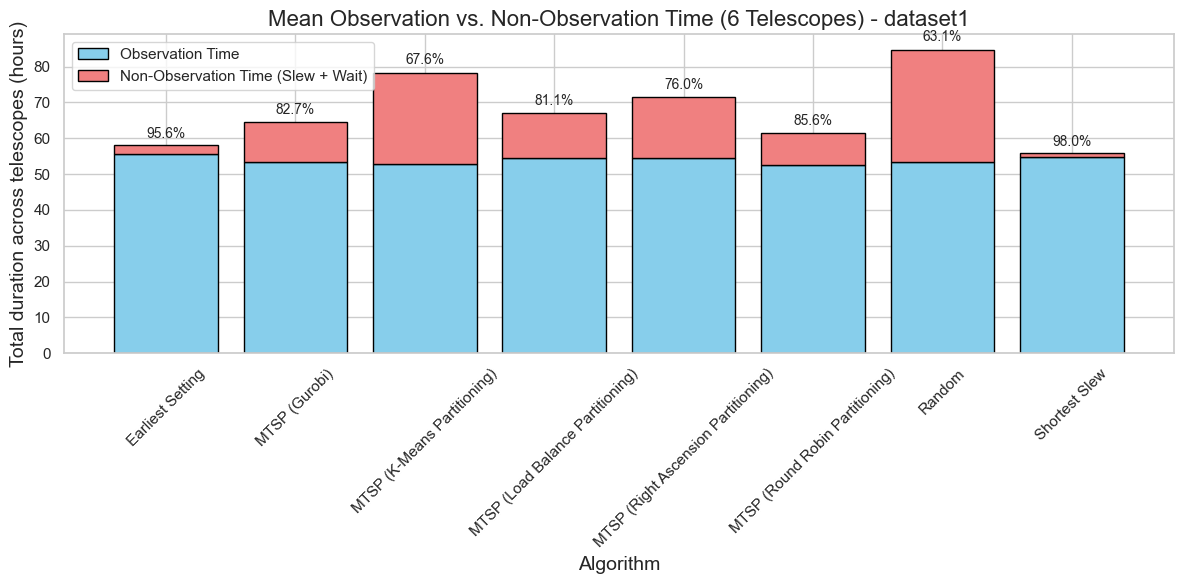

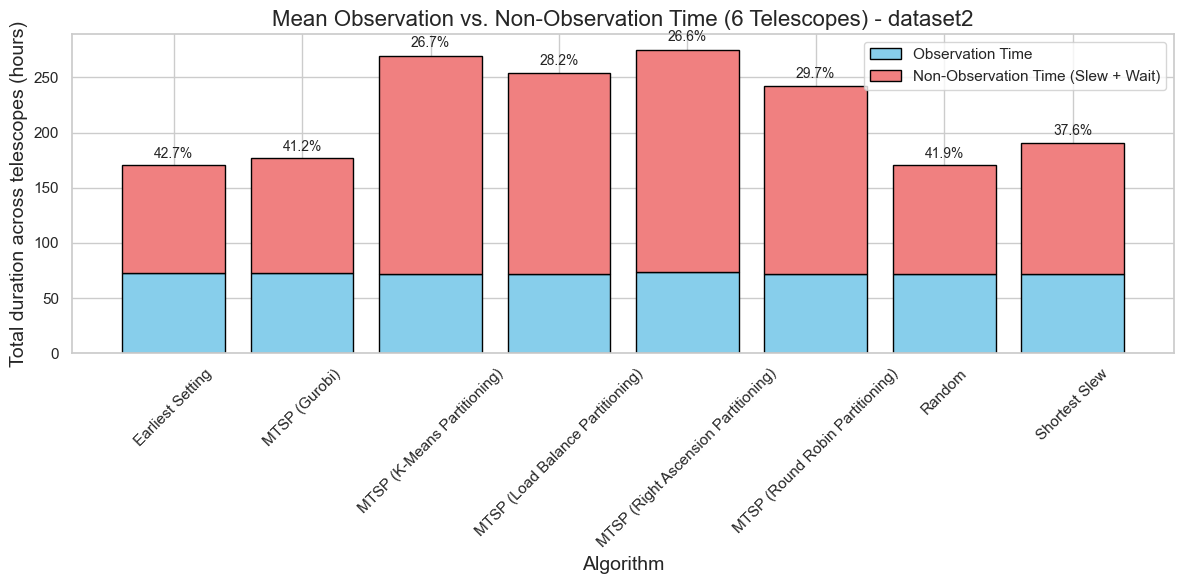

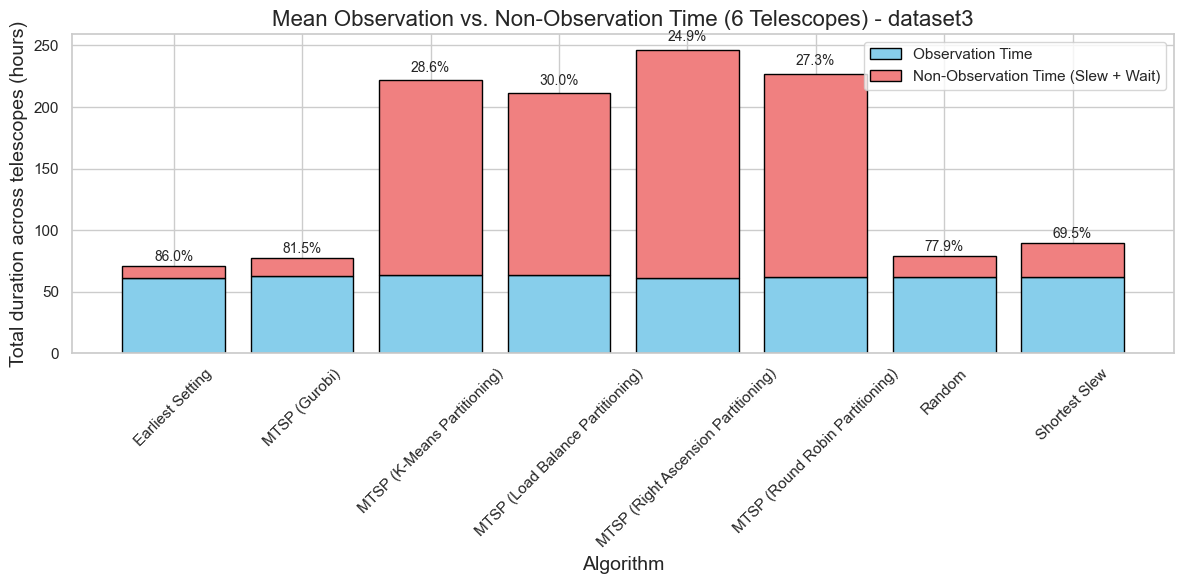

In [14]:
for dataset_name, df in dataset_dfs.items():
    if df.empty:
        print(f"Skipping {dataset_name} because it has no data.")
        continue

    # Group by Folder
    summary = df.groupby('Folder').agg({
        'Total Duration': 'mean',
        'Observation Time': 'mean'
    }).reset_index()

    summary['Non-Observation Time'] = summary['Total Duration'] - summary['Observation Time']

    # Sort consistently
    summary = summary.sort_values('Folder')

    # Plot
    plt.figure(figsize=(12, 6))

    # Stacked bar: Observation (bottom), Non-Observation (top)
    plt.bar(summary['Folder'], summary['Observation Time'], label='Observation Time', color='skyblue', edgecolor='black')
    plt.bar(summary['Folder'], summary['Non-Observation Time'], bottom=summary['Observation Time'],
            label='Non-Observation Time (Slew + Wait)', color='lightcoral', edgecolor='black')

    # Optionally overlay observation ratio text
    observation_ratio = summary['Observation Time'] / summary['Total Duration'] * 100
    for i, (obs, total) in enumerate(zip(summary['Observation Time'], summary['Total Duration'])):
        plt.text(i, total + 0.02 * total,
                 f"{observation_ratio.iloc[i]:.1f}%",
                 ha='center', va='bottom', fontsize=10)

    plt.title(f"Mean Observation vs. Non-Observation Time (6 Telescopes) - {dataset_name}", fontsize=16)
    plt.ylabel("Total duration across telescopes (hours)", fontsize=14)
    plt.xlabel("Algorithm", fontsize=14)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()
